<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/Lab-2/DeepLearning_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 1: Dataset Exploration

In [ ]:
# Load Fashion-MNIST dataset
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Print dataset dimensions
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")


Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


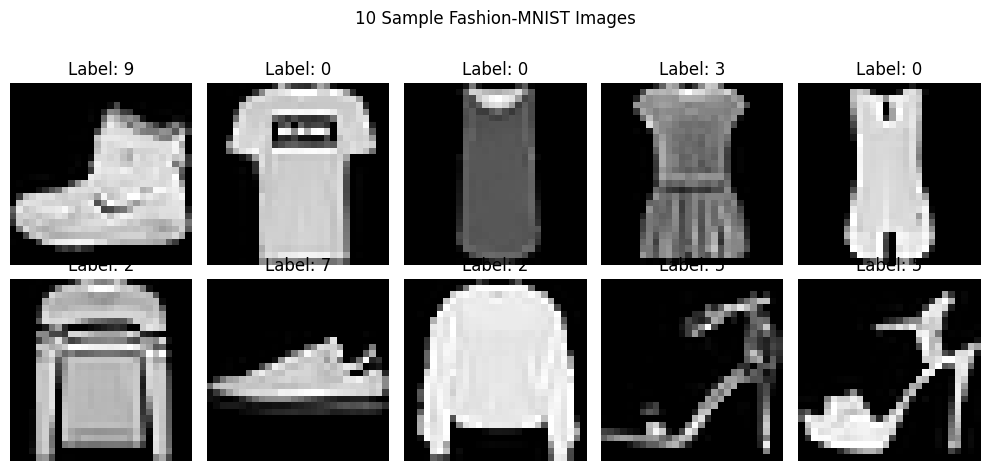

In [ ]:
# Display ten sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')
plt.suptitle('10 Sample Fashion-MNIST Images')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


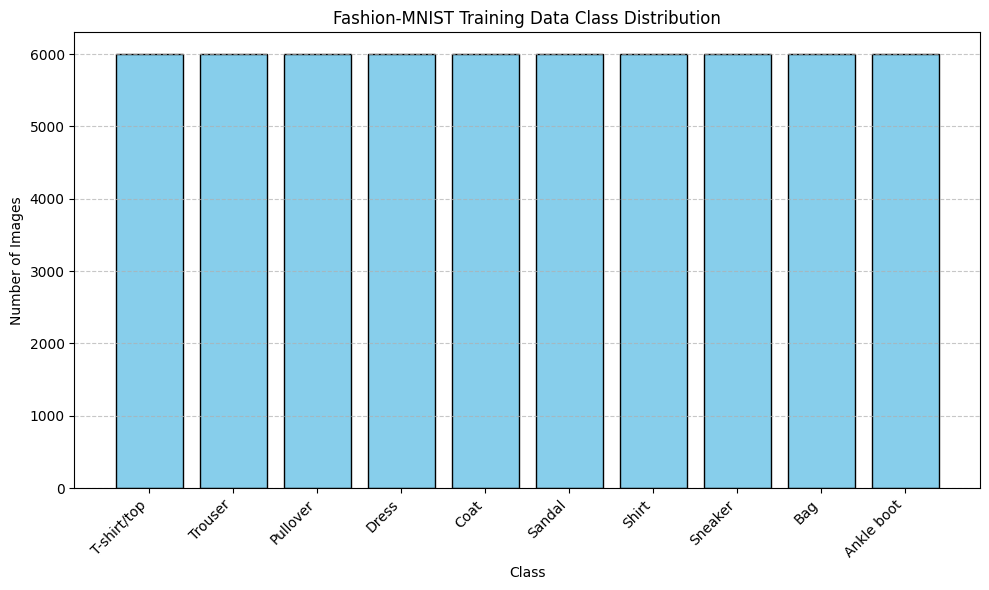

In [ ]:
# Plot class distribution
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(10, 6))
plt.hist(train_labels, bins=np.arange(len(class_names) + 1) - 0.5, rwidth=0.8, color='skyblue', edgecolor='black')
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45, ha='right')
plt.title('Fashion-MNIST Training Data Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Task 2: Data Preprocessing

In [ ]:
# Flatten images
# Reshape images from (num_images, 28, 28) to (num_images, 28 * 28)
train_images_flat = train_images.reshape((60000, 28 * 28))
test_images_flat = test_images.reshape((10000, 28 * 28))

# Normalize pixel values to be between 0 and 1
train_images_normalized = train_images_flat / 255.0
test_images_normalized = test_images_flat / 255.0


In [ ]:
# Print tensor shapes before and after preprocessing
print("--- Before Preprocessing ---")
print(f"Original training images shape: {train_images.shape}")
print(f"Original test images shape: {test_images.shape}")

print("\n--- After Preprocessing (Flattening and Normalization) ---")
print(f"Flattened and normalized training images shape: {train_images_normalized.shape}")
print(f"Flattened and normalized test images shape: {test_images_normalized.shape}")


--- Before Preprocessing ---
Original training images shape: (60000, 28, 28)
Original test images shape: (10000, 28, 28)

--- After Preprocessing (Flattening and Normalization) ---
Flattened and normalized training images shape: (60000, 784)
Flattened and normalized test images shape: (10000, 784)


### Task 3: Model Construction

In [ ]:
# Import necessary Keras modules
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Construct the MLP model
model = Sequential([
    # Input layer (784 features, automatically inferred by the first Dense layer's input_shape)
    Dense(128, activation='relu', input_shape=(784,)),
    # Hidden layer 1
    Dense(64, activation='relu'),
    # Output layer (10 classes with softmax activation)
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Display model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Task 4: Model Training

In [ ]:
# Compile the model
# Using SparseCategoricalCrossentropy because labels are integers (not one-hot encoded)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Train the model
history = model.fit(
    train_images_normalized,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_data=(test_images_normalized, test_labels)
)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8232 - loss: 0.4990 - val_accuracy: 0.8407 - val_loss: 0.4378
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8659 - loss: 0.3696 - val_accuracy: 0.8525 - val_loss: 0.3944
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8763 - loss: 0.3348 - val_accuracy: 0.8590 - val_loss: 0.3810
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8846 - loss: 0.3109 - val_accuracy: 0.8654 - val_loss: 0.3727
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8906 - loss: 0.2928 - val_accuracy: 0.8695 - val_loss: 0.3655
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8968 - loss: 0.2772 - val_accuracy: 0.8719 - val_loss: 0.3607
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9010 - loss: 0.2662 - val_accuracy: 0.8783 - val_loss: 0.3353
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9055 - loss: 0.2

### Task 5: Model Evaluation

In [ ]:
# Import necessary libraries for evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Make predictions on the test set
y_pred_probs = model.predict(test_images_normalized)
y_pred = np.argmax(y_pred_probs, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# 1. Compute and print Accuracy
accuracy = accuracy_score(test_labels, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8886


In [ ]:
# 2. Classification Report (includes Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(test_labels, y_pred, target_names=class_names))



Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.79      0.83      0.81      1000
       Dress       0.83      0.94      0.88      1000
        Coat       0.83      0.79      0.81      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.75      0.65      0.70      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



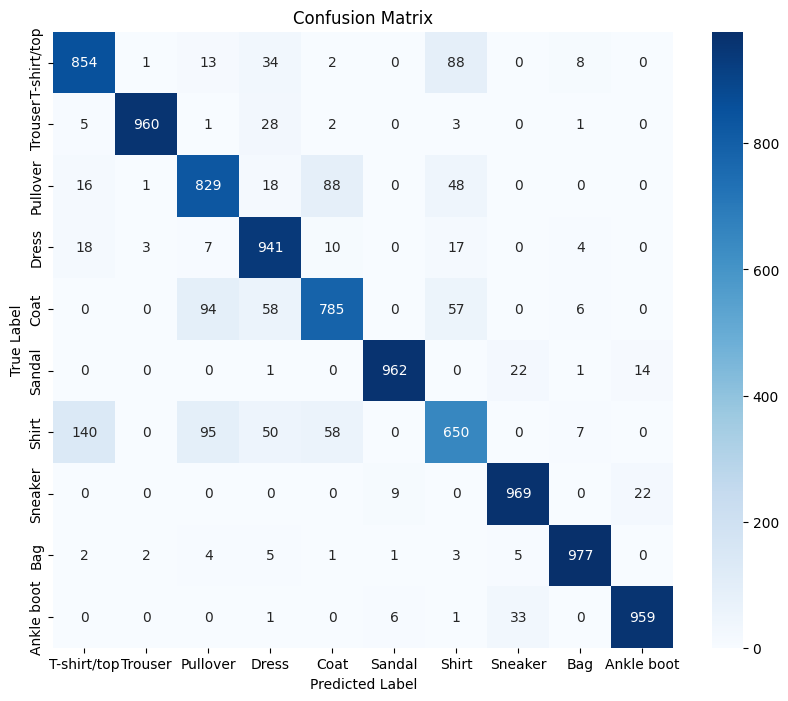

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


### Task 6: Hyperparameter Optimization

In [ ]:
# Install SciKeras and a compatible version of scikit-learn
!pip install scikeras scikit-learn==1.3.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 51.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of scikeras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.0 MB/s eta 0:00:00
  Created wheel for scikit-learn: filename=scikit_learn-1.3.0-cp312-cp312-linux_x86_64.whl size=10741759 sha256=75163d6961b36bb39ffb85b29c5b9008cf7ceeec65a5a210547a8be913ee764d
  Stored in directory: /root/.cache/pip/wheels/dc/e7/56/cae51184980f4c0f7bc63c40ccecad85060b79f19452e19b14
Successfully built scikit-learn
  Attempting uninstall: packaging
    Found existing installation: packaging 26.2
    Uninstalling packaging-26.2:
      Successfully uninstalled packaging-26.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define a function to create the Keras model, as required by SciKeras
def create_model(hidden_layers=1, hidden_neurons=128, learning_rate=0.001, activation='relu', dropout_rate=0.0):
    model = Sequential()
    # Input layer and first hidden layer
    model.add(Dense(hidden_neurons, activation=activation, input_shape=(784,)))
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))

    # Additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    # Define optimizer based on learning_rate
    if learning_rate is not None:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) # Use Adam with specified learning rate
    else:
        optimizer = 'adam'

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Wrap the Keras model in SciKeras' KerasClassifier
keras_model = KerasClassifier(model=create_model, verbose=0)

### Define the Hyperparameter Search Space

In [ ]:
# Define the hyperparameter search space
param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

# Initialize RandomizedSearchCV
# Using n_iter=20 for a reasonable number of random combinations to search
# cv=3 for 3-fold cross-validation (5 is too computationally intensive for many combinations)
random_search = RandomizedSearchCV(
    estimator=keras_model,
    param_distributions=param_dist,
    n_iter=20, # Number of parameter settings that are sampled
    cv=3, # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1, # Use all available cores
    scoring='accuracy'
)

print("Starting Randomized Search...")
# Fit RandomizedSearchCV
# Note: This step can take a significant amount of time depending on n_iter, cv, and model complexity.
random_search_result = random_search.fit(train_images_normalized, train_labels)
print("Randomized Search completed.")

### Record Best Hyperparameters and Retrain Optimized Model

In [ ]:
# Record the best hyperparameter combination
best_params = random_search_result.best_params_
best_score = random_search_result.best_score_

print(f"Best cross-validation accuracy: {best_score:.4f}")
print("Best hyperparameters found:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Retrain the model using the optimized hyperparameters
optimized_model = create_model(
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate']
)

print("\nTraining optimized model...")
history_optimized = optimized_model.fit(
    train_images_normalized,
    train_labels,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_data=(test_images_normalized, test_labels),
    verbose=1
)
print("Optimized model training completed.")

NameError: name 'random_search_result' is not defined

### Evaluate the Optimized Model and Compare with Baseline

In [ ]:
# Evaluate the optimized model on the testing dataset
print("\nEvaluating optimized model on test set...")
loss_optimized, accuracy_optimized = optimized_model.evaluate(test_images_normalized, test_labels, verbose=0)
print(f"Optimized Model Test Accuracy: {accuracy_optimized:.4f}")

# Make predictions with the optimized model
y_pred_optimized_probs = optimized_model.predict(test_images_normalized)
y_pred_optimized = np.argmax(y_pred_optimized_probs, axis=1)

# Classification Report for Optimized Model
print("\nOptimized Model Classification Report:")
print(classification_report(test_labels, y_pred_optimized, target_names=class_names))

# Confusion Matrix for Optimized Model
conf_matrix_optimized = confusion_matrix(test_labels, y_pred_optimized)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Optimized Model Confusion Matrix')
plt.show()

# Compare with the baseline model's performance
print("\n--- Comparison with Baseline Model ---")
print(f"Baseline Model Test Accuracy (from previous evaluation): {accuracy:.4f}")
print(f"Optimized Model Test Accuracy: {accuracy_optimized:.4f}")

if accuracy_optimized > accuracy:
    print("The optimized model performed better than the baseline model.")
elif accuracy_optimized < accuracy:
    print("The optimized model performed worse than the baseline model.")
else:
    print("The optimized model performed similarly to the baseline model.")


Evaluating optimized model on test set...


NameError: name 'optimized_model' is not defined